# Laboratorio 03: Fundamentos Estadísticos y Optimización

**Curso:** Inteligencia Artificial I - IS484  
**Estudiante:** Dhean Fernandez  
**Semana:** 03  
**Semestre:** 2026-II  

## Objetivo

Aplicar fundamentos estadísticos y conceptos básicos de optimización sobre datos de matrícula de la Escuela Profesional de Ingeniería de Sistemas, utilizando estadísticos descriptivos, correlación, función de error y descenso de gradiente.

## 4.2 Explorando el problema: ¿qué influye en la matrícula de cada semestre?

El dataset `matricula_sistemas.csv` contiene información histórica de matrícula de la Escuela Profesional de Ingeniería de Sistemas.

Las principales variables son:

- `num_postulantes`: número de estudiantes que postularon.
- `becas_otorgadas`: número de becas otorgadas.
- `tasa_desercion_anterior`: proporción de estudiantes que abandonaron el semestre anterior.
- `campania_difusion`: indica si se realizó una campaña de difusión (1 = sí, 0 = no).
- `num_matriculados`: número de estudiantes matriculados y variable objetivo.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

In [17]:
matricula = pd.read_csv("matricula_sistemas.csv")

matricula.head()


,semestre,num_postulantes,becas_otorgadas,tasa_desercion_anterior,campania_difusion,num_matriculados
0,2015-I,211,10,0.106,0,120
1,2015-II,179,9,0.115,0,88
2,2016-I,180,12,0.150,0,101
3,2016-II,146,8,0.151,0,75
4,2017-I,198,11,0.158,1,112


In [18]:
matricula.describe()

,num_postulantes,becas_otorgadas,tasa_desercion_anterior,campania_difusion,num_matriculados
count,24.000000,24.000000,24.000000,24.000000,24.000000
mean,231.125000,18.250000,0.129917,0.500000,137.083333
std,41.277757,6.917212,0.021055,0.510754,34.122435
min,146.000000,8.000000,0.096000,0.000000,75.000000
25%,200.250000,12.750000,0.110750,0.000000,111.500000
50%,222.500000,17.500000,0.127500,0.500000,137.000000
75%,261.250000,24.250000,0.150250,1.000000,161.500000
max,311.000000,30.000000,0.167000,1.000000,198.000000


### Parte B: Estadísticos descriptivos de la matrícula

Para comprender el comportamiento de la matrícula, se calcularán los principales estadísticos descriptivos de la variable `num_matriculados`: media, mediana, moda, rango, varianza y desviación estándar.

In [19]:
col = matricula["num_matriculados"]

print("Media:", col.mean())
print("Mediana:", col.median())
print("Moda:", col.mode().tolist())
print("Rango:", col.max() - col.min())
print("Varianza:", col.var())
print("Desviación estándar:", col.std())

Media: 137.08333333333334
Mediana: 137.0
Moda: [120, 137, 160]
Rango: 123
Varianza: 1164.340579710145
Desviación estándar: 34.12243513745971


### Cálculo de predicción y error por semestre

Se calculará la predicción del número de matriculados utilizando un valor de pendiente `w` y un intercepto `b`. Luego se comparará la predicción con el valor real para obtener el error de cada semestre.

In [20]:
postulantes = matricula["num_postulantes"]

# Normalización
postulantes_norm = (postulantes - postulantes.mean()) / postulantes.std()

# Parámetros del modelo
w = 32
b = 137.1

# Predicción
prediccion = w * postulantes_norm + b

# Error = valor real - valor predicho
error = matricula["num_matriculados"] - prediccion

# Tabla de resultados
tabla_error = pd.DataFrame({
    "Semestre": matricula["semestre"],
    "x_normalizado": postulantes_norm.round(2),
    "Matricula_real": matricula["num_matriculados"],
    "Prediccion": prediccion.round(2),
    "Error": error.round(2)
})

tabla_error

,Semestre,x_normalizado,Matricula_real,Prediccion,Error
0,2015-I,-0.49,120,121.50,-1.50
1,2015-II,-1.26,88,96.69,-8.69
2,2016-I,-1.24,101,97.47,3.53
3,2016-II,-2.06,75,71.11,3.89
4,2017-I,-0.80,112,111.42,0.58
5,2017-II,-0.83,98,110.65,-12.65
6,2018-I,-0.83,102,110.65,-8.65
7,2018-II,-0.34,110,126.15,-16.15
8,2019-I,-0.17,130,131.58,-1.58
9,2019-II,-0.73,117,113.75,3.25


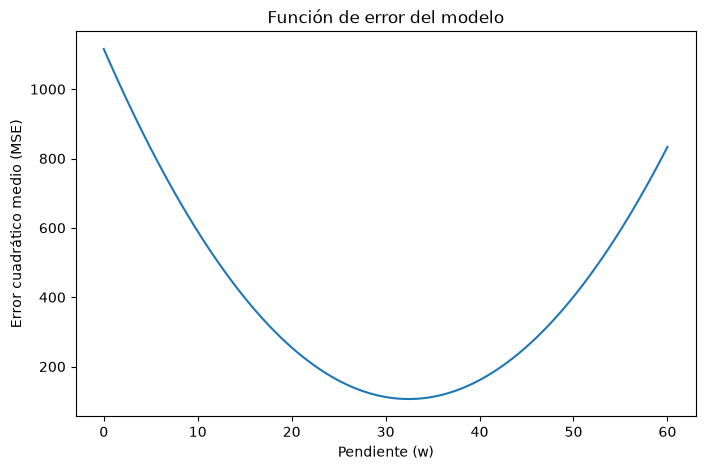

In [21]:
postulantes = matricula["num_postulantes"]
postulantes_norm = (postulantes - postulantes.mean()) / postulantes.std()
matriculados = matricula["num_matriculados"].astype(float)

b_fijo = 137.1
valores_w = np.linspace(0, 60, 100)

errores = []

for w in valores_w:
    prediccion = w * postulantes_norm + b_fijo
    mse = np.mean((prediccion - matriculados) ** 2)
    errores.append(mse)

plt.figure(figsize=(8, 5))
plt.plot(valores_w, errores)

plt.xlabel("Pendiente (w)")
plt.ylabel("Error cuadrático medio (MSE)")
plt.title("Función de error del modelo")

plt.show()

## 4.3 Visualización de la función de error

Se utilizará la variable `num_postulantes`, ya que presenta una relación importante con el número de matriculados.

La variable se normaliza para trabajar en una escala más manejable. Luego se probarán distintos valores de la pendiente `w` y se calculará el error cuadrático medio (MSE) para identificar qué valor produce el menor error.

In [22]:
postulantes = matricula["num_postulantes"]

postulantes_norm = (
    postulantes - postulantes.mean()
) / postulantes.std()

matriculados = matricula["num_matriculados"].astype(float)

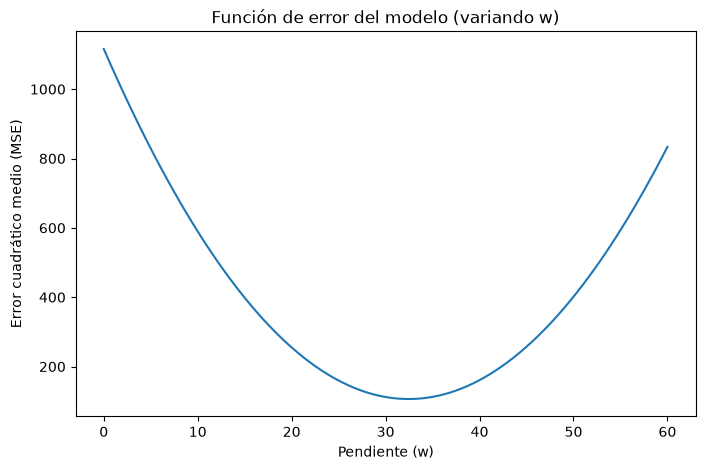

In [23]:
b_fijo = 137.1

valores_w = np.linspace(0, 60, 100)
errores = []

for w in valores_w:
    prediccion = w * postulantes_norm + b_fijo
    mse = np.mean((prediccion - matriculados) ** 2)
    errores.append(mse)

plt.figure(figsize=(8, 5))
plt.plot(valores_w, errores)

plt.xlabel("Pendiente (w)")
plt.ylabel("Error cuadrático medio (MSE)")
plt.title("Función de error del modelo (variando w)")

plt.show()

## 4.4 Descenso de gradiente

El descenso de gradiente es un método de optimización que ajusta progresivamente los parámetros `w` y `b` con el objetivo de reducir el error del modelo.

El procedimiento comienza con valores iniciales de `w = 0` y `b = 0`, y en cada paso se calculan los gradientes para actualizar ambos parámetros.

In [ ]:
w, b = 0.0, 0.0

tasa_aprendizaje = 0.3
n = len(postulantes_norm)

for paso in range(1, 11):
    prediccion = w * postulantes_norm + b

    error = prediccion - matriculados

    mse = np.mean(error ** 2)

    gradiente_w = (2 / n) * np.sum(error * postulantes_norm)
    gradiente_b = (2 / n) * np.sum(error)

    w = w - tasa_aprendizaje * gradiente_w
    b = b - tasa_aprendizaje * gradiente_b

    print(
        f"Paso {paso}: "
        f"MSE={mse:.2f} "
        f"w={w:.2f} "
        f"b={b:.2f}"
    )


Paso 1: MSE=19907.67 w=18.66 b=82.25
Paso 2: MSE=3295.39 w=26.59 b=115.15
Paso 3: MSE=620.37 w=29.96 b=128.31
Paso 4: MSE=189.29 w=31.40 b=133.57
Paso 5: MSE=119.76 w=32.01 b=135.68
Paso 6: MSE=108.53 w=32.26 b=136.52
Paso 7: MSE=106.72 w=32.37 b=136.86
Paso 8: MSE=106.42 w=32.42 b=136.99
Paso 9: MSE=106.37 w=32.44 b=137.05
Paso 10: MSE=106.37 w=32.45 b=137.07
